# **PROJECT - Explainable Financial Fraud Detection System with Risk Analysis and Chatbot Interface**

**Project Introduction**

This project focuses on building an end-to-end financial fraud detection system using machine learning and explainable AI techniques. The system identifies fraudulent transactions and provides human-readable explanations for predictions.

Additionally, an interactive chatbot interface is developed to allow users to query prediction results, risk factors, and model insights. The objective is to create a practical and interpretable fraud detection solution suitable for real-world financial applications.

**Problem Statement**

Financial institutions process millions of transactions daily, making manual fraud detection difficult and inefficient. Traditional models often provide predictions without explanations, making it challenging for analysts to trust the system.

Therefore, there is a need for an intelligent system that not only detects fraudulent transactions but also explains the reasoning behind the predictions in a clear and interpretable manner.

**Project Objectives**

- Build a machine learning model to detect fraudulent transactions
- Handle highly imbalanced fraud dataset
- Identify important features contributing to fraud prediction
- Develop an explainable AI layer for interpretability
- Create an interactive chatbot for user queries
- Provide confidence score using prediction probability
- Design an end-to-end fraud detection pipeline

**Project Pipeline**

Data Loading → Data Cleaning → EDA → Feature Engineering → Train/Test Split → Scaling → Handle Imbalance (using SMOTE) → Model Training → Model Evaluation → Best Model Selection → Anomaly Detection (Isolation Forest) → Explanation Layer → Chatbot Interface → Final Output

# **Phase 1: Machine Learning Fraud Detection**

In Phase 1, multiple machine learning models were trained to detect fraudulent transactions. Logistic Regression and Random Forest were evaluated using precision, recall, F1-score, and confusion matrix. Since fraud cases are rare, therefore using Isolation forest model to detect anomalies.

Phase 1 includes:

- Data preprocessing
- Handling imbalanced data
- Model training
- Model comparison
- Final model selection
- Fraud probability prediction
- Anomaly Detection (Isolation Forest)

# **Data Loading**

In [99]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [100]:
# Loading dataset
import pandas as pd

file_path = "/content/drive/MyDrive/Fraud detection/creditcard.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [101]:
# Importing Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [102]:
# Loading the Dataset

df = pd.read_csv("/content/creditcard.csv")

In [103]:
# Viewing the First Few Rows

# it shows the first five rows of the dataset
df.head()

# Insights: The following columns indicate:
# Time - Time of transaction
# V1–V28 - anonymized features created using PCA(encoded features)
# Amount - Transaction amount
# Class - Target variable (0 = normal, 1 = fraud)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# **Data Cleaning**

In [104]:
# Checking Dataset Shape

df.shape

# Insights- we have 284807 rows and 31 columns

(284807, 31)

In [105]:
# Checking Column Names

df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [106]:
# Checking Dataset Information

df.info()

# Insights- It shows all the columns are numeric

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [107]:
# Statistical Summary

df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.759061e-12,-8.251130e-13,-9.654937e-13,8.321385e-13,1.649999e-13,4.248366e-13,-3.054600e-13,8.777971e-14,-1.179749e-12,...,-3.405756e-13,-5.723197e-13,-9.725856e-13,1.464150e-12,-6.987102e-13,-5.617874e-13,3.332082e-12,-3.518874e-12,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [108]:
# Checking Missing Values

df.isnull().sum()

# Insights- No null values exist

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [109]:
# Checking Duplicate Rows

df.duplicated().sum()

# Insights- We have 1081 duplicated rows exist

np.int64(1081)

In [110]:
# Removing Duplicate Rows

df = df.drop_duplicates()

In [111]:
# Checking again for duplicate rows, now there are no duplicates in the dataset

df.duplicated().sum()

np.int64(0)

In [112]:
# Verifing Shape Again

df.shape

# Insights- Now we have 283726 rows, earlier we had 284807 rows which means 284807 - 283726 = 1081 rows were duplicated

(283726, 31)

In [113]:
# Checking Target Variable Distribution

# Our Target Variable is class column which tells us how many normal transactions and how many fraud transactions happens
# 0 shows normal transaction whereas 1 shows flag means fraud transaction

df['Class'].value_counts()

# Insights- It shows 283253 normal transactions and 473 fraud transactions.
#           It also indicates we have class imbalance problem as we have very few fraud transactions compared to normal transactions.

,count
Class,
0,283253
1,473


In [114]:
# Checking Target Variable in Percentage

df['Class'].value_counts(normalize=True) * 100

# Insights- We have 99.8% normal and 0.2% fraud transactions

,proportion
Class,
0,99.83329
1,0.16671


# **EDA- Exploratory Data Analysis**

In [115]:
# Understanding Feature Types

df.dtypes

# Insights - It shows V1–V28, Amount, Time are numeric feature and Class is categorical feature (binary)

,0
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


**Univariate Analysis - Analyze one variable at a time**

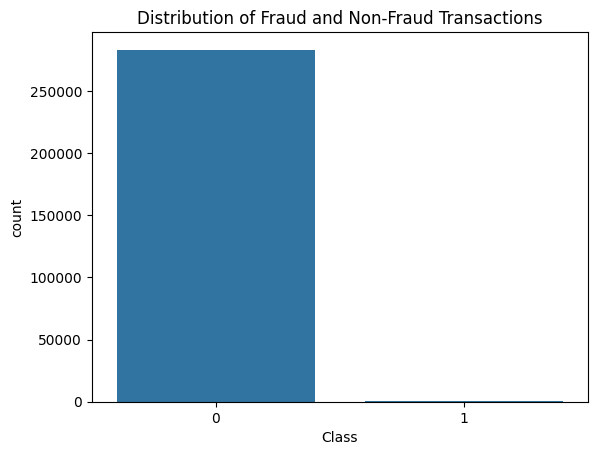

In [116]:
# Ploting Class Distribution

sns.countplot(x = 'Class', data = df)
plt.title('Distribution of Fraud and Non-Fraud Transactions')
plt.show()

# Insights - Fraud cases are very less which shows dataset is highly imbalanced

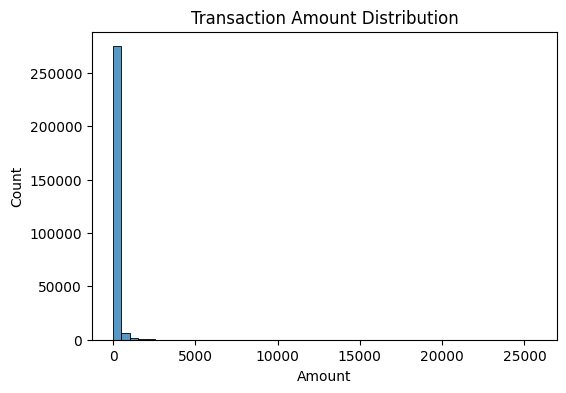

In [117]:
# Amount Distribution

plt.figure(figsize=(6,4))
sns.histplot(df['Amount'], bins= 50)
plt.title("Transaction Amount Distribution")
plt.show()

# Insights - Most of the transactions are small and few are high-value transactions
#            which shows there may be the possibilty of fraud transactions in this few high-value transactions

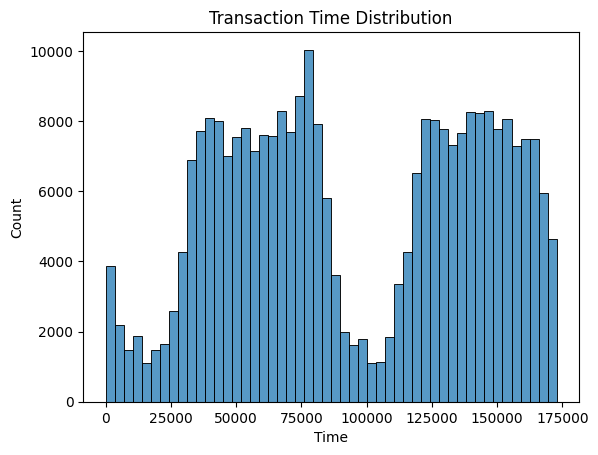

In [118]:
# Time Distribution

sns.histplot(df["Time"], bins= 50)
plt.title("Transaction Time Distribution")
plt.show()

# Insights - Transactions are distributed across the entire time range, indicating continuous activity.
#            However, certain time intervals show higher transaction density which shows peak transaction periods.

**Outlier Detection**

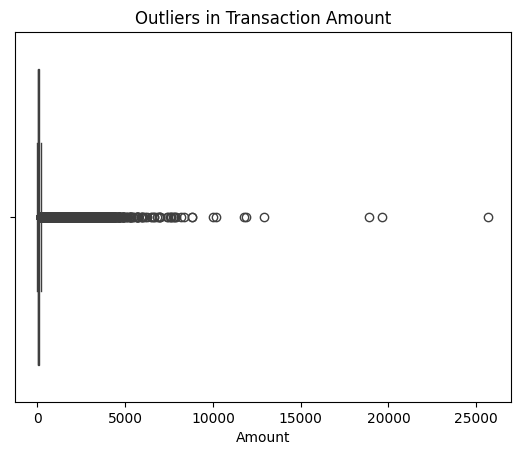

In [119]:
sns.boxplot(x= df['Amount'])
plt.title("Outliers in Transaction Amount")
plt.show()

# Insights - Fraud often happens in extreme values and we can observe those extreme values near amount of 20-25K

**Bivariate Analysis - Comparing 2 variables**

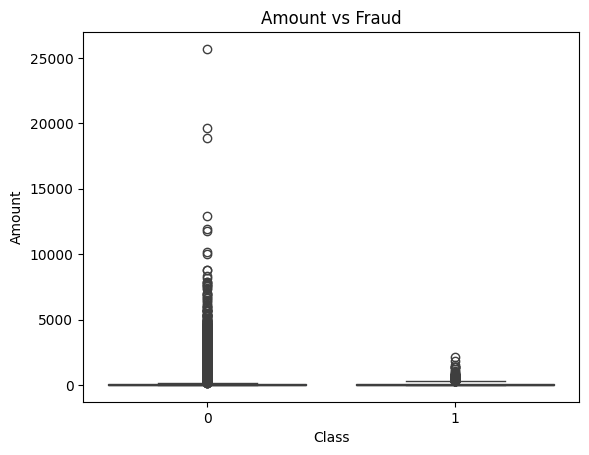

In [120]:
# Amount vs Class

sns.boxplot(x= 'Class', y= 'Amount', data= df)
plt.title("Amount vs Fraud")
plt.show()

# Insights - Here we get to know about an important information that fraudulent transactions primarily occur at lower amounts
#            as indicated by the concentration of data points near zero.
#            However, there are several significant outliers, with some fraudulent transactions reaching amounts over 20,000.

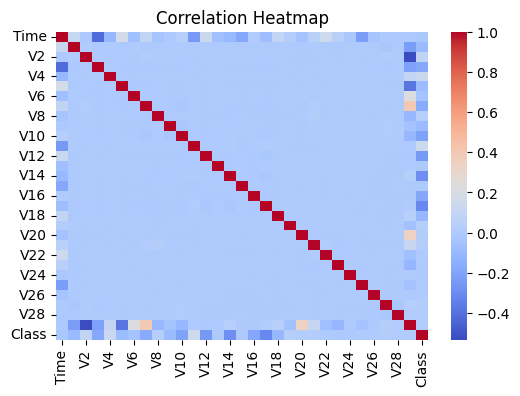

In [121]:
# Correlation Analysis

corr= df.corr()

plt.figure(figsize= (6,4))
sns.heatmap(corr, cmap= 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Multivariate Analysis- analyzing multiple variables together**

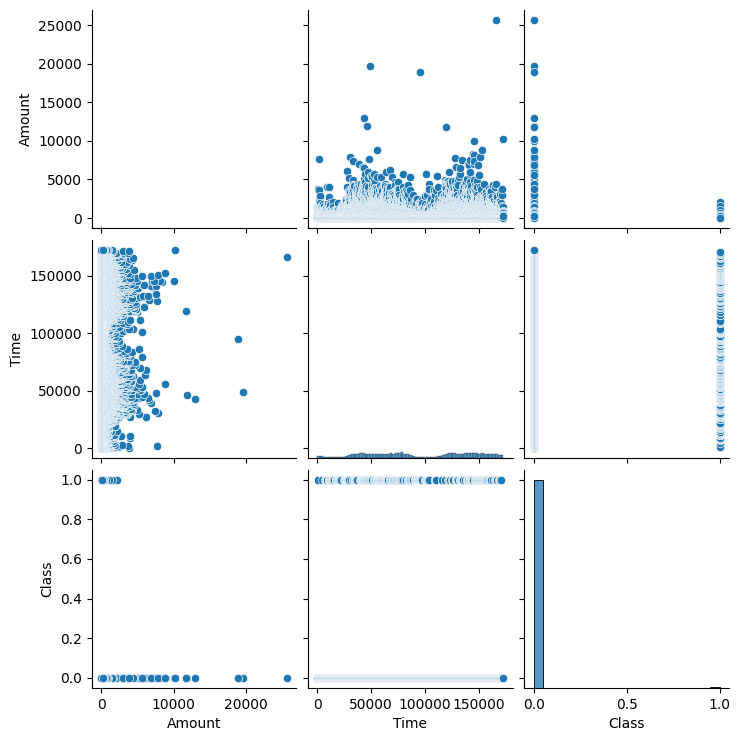

In [122]:
# Feature Relationship

sns.pairplot(df[['Amount', 'Time', 'Class']])
plt.show()

In [123]:
# Fraud vs Non-Fraud Feature Behavior

fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

print("Fraud Transactions:", fraud.shape)
print("Normal Transactions:", normal.shape)

Fraud Transactions: (473, 31)
Normal Transactions: (283253, 31)


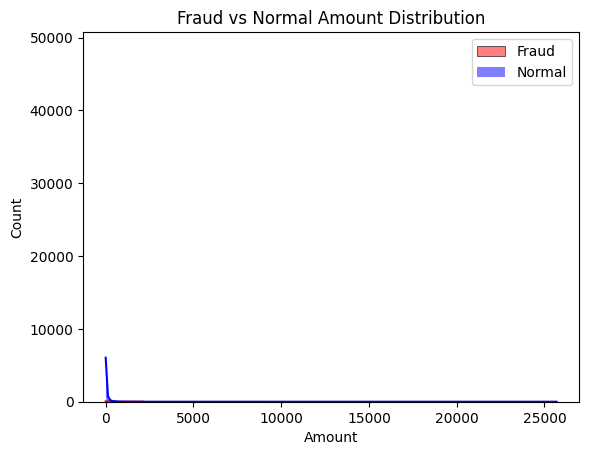

In [124]:
# Feature Distribution Comparison

sns.histplot(fraud['Amount'], color= 'red', label= 'Fraud', kde= True)
sns.histplot(normal['Amount'], color= 'blue', label= 'Normal', kde= True)
plt.legend()
plt.title('Fraud vs Normal Amount Distribution')
plt.show()

**Key Insights after EDA:**

- Dataset is highly imbalanced

- Fraud transactions are rare

- Amount distribution is skewed

- Some features show different behavior in fraud vs normal

- Outliers exist and are important

# **Feature Engineering**

In [125]:
# converts seconds into hours

df['Hour'] = df['Time'] / 3600

In [126]:
df[['Time', 'Hour']].head()

,Time,Hour
0,0.0,0.000000
1,0.0,0.000000
2,1.0,0.000278
3,1.0,0.000278
4,2.0,0.000556


In [127]:
# Defining Features and Target

# features = input columns (except class column)
# target = output column to predict (class)

x = df.drop('Class', axis = 1)
y = df['Class']

In [128]:
# Checking Shapes of X and y

print("Shape of x:", x.shape)
print("Shape of y:", y.shape)

Shape of x: (283726, 31)
Shape of y: (283726,)


**Train/Test Split**

In [129]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42, stratify= y)

In [130]:
# Checking Shapes After Split

print("x_train shape: ", x_train.shape)
print("x_test shape: ", x_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)

x_train shape:  (226980, 31)
x_test shape:  (56746, 31)
y_train shape:  (226980,)
y_test shape:  (56746,)


In [131]:
# Checking Class Distribution in Train/Test

print("Training target distribution :", y_train.value_counts(normalize= True) * 100)
print("Testing target distribution :", y_test.value_counts(normalize= True) * 100)

Training target distribution : Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64
Testing target distribution : Class
0    99.832587
1     0.167413
Name: proportion, dtype: float64


**Feature Scaling**

In [132]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train[['Amount', 'Time', 'Hour']] = scaler.fit_transform(x_train[['Amount', 'Time', 'Hour']])
x_test[['Amount', 'Time', 'Hour']] = scaler.transform(x_test[['Amount', 'Time', 'Hour']])

In [133]:
x_train[['Amount', 'Time', 'Hour']].head()

,Amount,Time,Hour
226238,-0.229434,1.045499,1.045499
134253,-0.331197,-0.298690,-0.298690
186465,-0.298809,0.678397,0.678397
149493,-0.289247,-0.074929,-0.074929
18461,-0.261985,-1.376728,-1.376728


**Handling Class Imbalance using SMOTE**

In [134]:
from imblearn.over_sampling import SMOTE

smote= SMOTE(random_state= 42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

In [135]:
# Checking Class Distribution After SMOTE

print("Original training class distribution :", y_train.value_counts())
print("Resampled training class distribution :", y_train_resampled.value_counts())

Original training class distribution : Class
0    226602
1       378
Name: count, dtype: int64
Resampled training class distribution : Class
0    226602
1    226602
Name: count, dtype: int64


# **Model Building**

**Logistic Regression**

In [136]:
# Using X_train_resampled and y_train_resampled because after SMOTE, the training data is balanced.

# Using X_test and y_test original because test data should stay realistic.

In [137]:
# Training a Logistic Regression model as a baseline because it is simple and suitable for binary classification

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state= 42)
lr_model.fit(x_train_resampled, y_train_resampled)

LogisticRegression(random_state=42)

In [138]:
# Predictions with Logistic Regression

y_pred_lr = lr_model.predict(x_test)

In [139]:
# Evaluating Logistic Regression

# In fraud detection, accuracy alone is not enough. Recall for fraud class is very important

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Logistic Regression Accuracy :", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy : 0.9737955098156699

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746


Confusion Matrix:
 [[55176  1475]
 [   12    83]]


In [140]:
# Insights - The Logistic Regression model shows high overall accuracy, but due to class imbalance, this metric is misleading.
#            The model performs very well on non-fraud transactions, but for fraud detection, it has high recall and very low precision.
#            This means it successfully detects most fraud cases but generates a large number of false positives,
#            which can lead to operational inefficiencies.

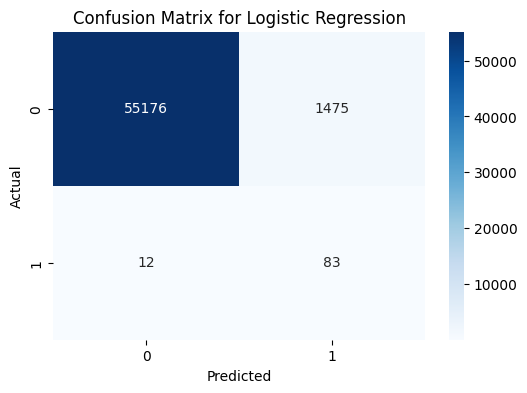

In [141]:
# Ploting Confusion Matrix for Logistic Regression

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize= (6,4))
sns.heatmap(cm_lr, annot = True, fmt= 'd', cmap= 'Blues')
plt.title("Confusion Matrix for Logistic Regression")
plt.xlabel('Predicted')
plt.ylabel("Actual")
plt.show()

**Random Forest Model**

In [142]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42,
    n_jobs =-1
)

In [143]:
rf_model.fit(x_train_resampled, y_train_resampled)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [144]:
# Predictions with Random Forest

y_pred_rf = rf_model.predict(x_test)

In [145]:
# Evaluating Random Forest

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Random Forest Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Random Forest Classification report \n:", classification_report(y_test, y_pred_rf))
print("Random Forest Confusion matrix \n:", confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy : 0.9994360836006062
Random Forest Classification report 
:               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.74      0.81        95

    accuracy                           1.00     56746
   macro avg       0.95      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746

Random Forest Confusion matrix 
: [[56644     7]
 [   25    70]]


In [146]:
# Insights - I compared Logistic Regression and Random Forest for fraud detection.
#            Logistic Regression had higher recall but extremely low precision, resulting in many false positives.
#            Random Forest significantly improved precision while maintaining good recall,
#            leading to a much better F1-score. Fraud detection requires a balance between detecting fraud and minimizing false alarms,
#            I am selecting Random Forest as the final model.

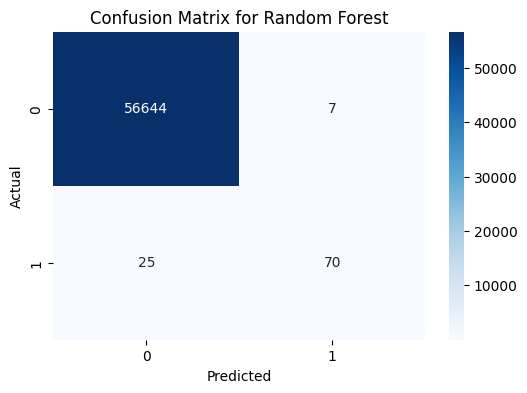

In [147]:
# Ploting Confusion Matrix for Random Forest

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize= (6,4))
sns.heatmap(cm_rf, cmap = 'Blues', annot= True, fmt = 'd')
plt.title("Confusion Matrix for Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Feature Importance from Random Forest**

In [148]:
# This helps us understand which features contributed most to prediction

feature_importance = pd.DataFrame({
    'Feature': x_train_resampled.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

   Feature  Importance
14     V14    0.198973
10     V10    0.154481
12     V12    0.099636
4       V4    0.076052
11     V11    0.075695
17     V17    0.074776
3       V3    0.038605
16     V16    0.038309
7       V7    0.030429
2       V2    0.026700


In [149]:
top_features = feature_importance.head(5)['Feature'].tolist()
print("Top important features:", top_features)

Top important features: ['V14', 'V10', 'V12', 'V4', 'V11']


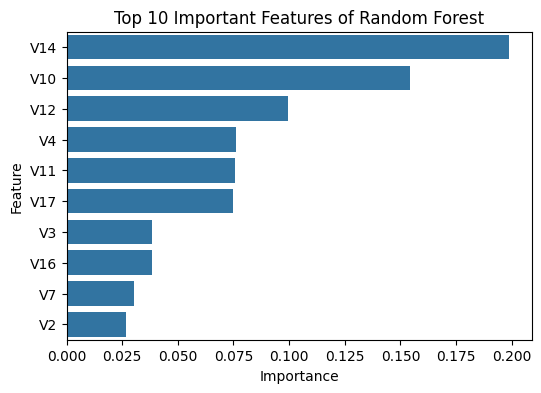

In [150]:
# Ploting Feature Importance

plt.figure(figsize= (6,4))
sns.barplot(x= 'Importance', y="Feature", data= feature_importance.head(10))
plt.title("Top 10 Important Features of Random Forest")
plt.show()

# **Anomaly Detection (Isolation Forest)**

In [151]:
# Isolation Forest is an anomaly detection algorithm. It returns 1 for normal points and -1 for anomalies.
# Since anomaly detection works better on the original pattern, we use x_train, x_test

# Training Isolation Forest

from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.002,
    random_state=42,
    n_jobs=-1
)

iso_model.fit(x_train)

IsolationForest(contamination=0.002, n_jobs=-1, random_state=42)

In [152]:
# Predicting Anomalies on Test Data

y_pred_iso = iso_model.predict(x_test)

In [153]:
# Checking Raw Predictions

np.unique(y_pred_iso, return_counts= True)

# Insights - It shows 118 to be flagged as anomalies and 56628 to be normal.

(array([-1,  1]), array([  118, 56628]))

In [154]:
# Converting Isolation Forest Output to Fraud Labels

y_pred_iso = np.where(y_pred_iso == -1, 1, 0)

In [155]:
# Evaluating Isolation Forest

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Isolation Forest Accuracy:", accuracy_score(y_test, y_pred_iso))
print("\nClassification Report:\n", classification_report(y_test, y_pred_iso))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_iso))

Isolation Forest Accuracy: 0.9971980403905121

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.23      0.28      0.25        95

    accuracy                           1.00     56746
   macro avg       0.61      0.64      0.63     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
 [[56560    91]
 [   68    27]]


In [156]:
# Insights = Since fraud cases are rare, therefore using Isolation forest model to detect anomalies
#            but it failed to detect any fraud cases and predicted all transactions as normal.
#            This highlights a limitation of unsupervised methods in this dataset.
#            Therefore, I relied on Random Forest, which provided a better balance between precision and recall.

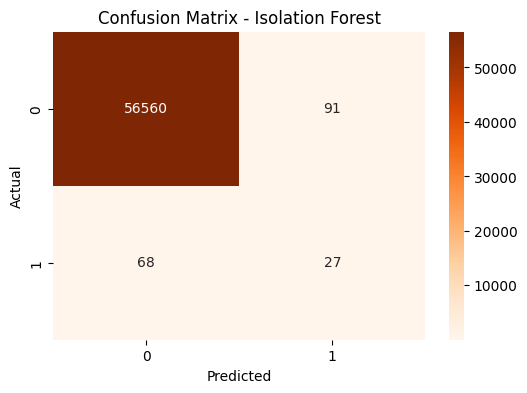

In [157]:
# Ploting Confusion Matrix

cm_iso = confusion_matrix(y_test, y_pred_iso)

plt.figure(figsize=(6,4))
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - Isolation Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# **Phase 2: Explainable AI + Chatbot Layer**

Phase 2 focuses on improving model interpretability. The most important features from the Random Forest model were extracted, and each transaction was compared with normal behavior patterns. If significant deviations were observed, they were identified as risk factors. A rule-based explanation layer was built to generate human-readable reasoning. Additionally, a chatbot interface was developed to allow users to interactively query prediction results.

Phase 2 includes:

- Feature importance extraction
- Risk factor identification
- Explanation generation
- Prediction confidence scoring
- Interactive chatbot interface

# **AI-Based Risk Explanation**

In [169]:
# Step 1: Getting top important features
top_features = feature_importance.head(5)['Feature'].tolist()
print("Top important features:", top_features)

# Insights - It takes the top 5 most important columns from Random Forest

Top important features: ['V14', 'V10', 'V12', 'V4', 'V11']


In [170]:
# Step 2: Selecting one sample transaction
sample_transaction = x_test.iloc[0]
print("\nSample Transaction:\n", sample_transaction)

# Insights - It selects one row from the test data


Sample Transaction:
 Time     -0.707761
V1        1.228821
V2       -0.063408
V3        0.274145
V4        0.647465
V5       -0.048135
V6        0.372073
V7       -0.224231
V8        0.079939
V9        0.640759
V10      -0.273054
V11      -1.252728
V12       0.465079
V13       0.400502
V14      -0.292842
V15      -0.101774
V16      -0.399836
V17       0.034336
V18      -0.783550
V19       0.141345
V20      -0.096566
V21      -0.129554
V22      -0.083779
V23      -0.151661
V24      -0.700372
V25       0.598550
V26       0.491409
V27       0.002989
V28       0.001782
Amount   -0.312846
Hour     -0.707761
Name: 86568, dtype: float64


In [171]:
# Step 3: Predicting fraud status
sample_prediction = rf_model.predict([sample_transaction])[0]
print("\nPrediction:", "Fraud" if sample_prediction == 1 else "Non-Fraud")

# Insights - It predicts whether that one transaction is fraud or not


Prediction: Non-Fraud


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [172]:
# Step 4: Computing normal mean values
normal_means = x_train.mean()
print("\nNormal Mean Values for Top Features:\n", normal_means[top_features])

# Insights - It calculates average values for features from training data.
#            This acts like “normal behavior reference.”


Normal Mean Values for Top Features:
 V14   -0.001629
V10   -0.002180
V12    0.000046
V4    -0.002025
V11    0.000080
dtype: float64


In [173]:
# Step 5: Explanation function
def explain_transaction(transaction, top_features, normal_means, threshold=2):
    explanations = []

    for feature in top_features:
        value = transaction[feature]
        mean_value = normal_means[feature]

        if abs(value - mean_value) > threshold:
            explanations.append(f"{feature} is significantly different from normal")

    if len(explanations) == 0:
        return "Transaction looks close to normal behavior."
    else:
        return "Risk factors: " + ", ".join(explanations)

In [174]:
# Step 6: Generating explanation
sample_explanation = explain_transaction(sample_transaction, top_features, normal_means)

In [175]:
# Step 7: Final output
print("\nFinal Output")
print("Prediction:", "Fraud" if sample_prediction == 1 else "Non-Fraud")
print("Explanation:", sample_explanation)


Final Output
Prediction: Non-Fraud
Explanation: Transaction looks close to normal behavior.


**Checking the AI Model response with one fraud and normal transaction**

In [176]:
# Step 1: Finding one fraud row from test set

fraud_index = y_test[y_test == 1].index[0]
fraud_transaction = x_test.loc[fraud_index]
fraud_actual = y_test.loc[fraud_index]

print("Fraud Index:", fraud_index)
print("Actual Class:", fraud_actual)

Fraud Index: 116139
Actual Class: 1


In [177]:
# Step 2: Finding one normal row from test set

normal_index = y_test[y_test == 0].index[0]
normal_transaction = x_test.loc[normal_index]
normal_actual = y_test.loc[normal_index]

print("Normal Index:", normal_index)
print("Actual Class:", normal_actual)

Normal Index: 86568
Actual Class: 0


In [183]:
def get_risk_factors(transaction, top_features, normal_means, threshold=2):
    risk_factors_list = []
    for feature in top_features:
        value = transaction[feature]
        mean_value = normal_means[feature]
        if abs(value - mean_value) > threshold:
            risk_factors_list.append(f"{feature} is significantly different from normal")
    return risk_factors_list

def generate_explanation(prediction, risk_factors_list):
    if prediction == 1: # Fraud
        if len(risk_factors_list) == 0:
            return "This transaction is predicted as Fraud, but no specific risk factors were identified based on the top features."
        else:
            return "This transaction is predicted as Fraud due to: " + ", ".join(risk_factors_list)
    else: # Non-Fraud
        if len(risk_factors_list) == 0:
            return "Transaction looks close to normal behavior."
        else:
            return "This transaction is predicted as Non-Fraud, but has some deviations: " + ", ".join(risk_factors_list)

In [185]:
# Step 3: Testing fraud transaction

fraud_prediction = rf_model.predict(fraud_transaction.to_frame().T)[0]

fraud_proba = rf_model.predict_proba(fraud_transaction.to_frame().T)

fraud_risk_factors = get_risk_factors(fraud_transaction, top_features, normal_means)
fraud_explanation = generate_explanation(fraud_prediction, fraud_risk_factors)

print("\n--- Fraud Transaction Test ---")
print("Actual Class:", "Fraud" if fraud_actual == 1 else "Non-Fraud")
print("Predicted Class:", "Fraud" if fraud_prediction == 1 else "Non-Fraud")
print("Prediction Probability:", fraud_proba)
print("Risk Factors:", fraud_risk_factors)
print("Explanation:", fraud_explanation)


--- Fraud Transaction Test ---
Actual Class: Fraud
Predicted Class: Fraud
Prediction Probability: [[0.01 0.99]]
Risk Factors: ['V14 is significantly different from normal', 'V10 is significantly different from normal', 'V12 is significantly different from normal', 'V4 is significantly different from normal', 'V11 is significantly different from normal']
Explanation: This transaction is predicted as Fraud due to: V14 is significantly different from normal, V10 is significantly different from normal, V12 is significantly different from normal, V4 is significantly different from normal, V11 is significantly different from normal


In [186]:
# Fraud probability

fraud_prob = fraud_proba[0][1]

print(f"Fraud Probability: {fraud_prob:.2f}")

# Insights - There is a 99% chance this transaction is fraud

Fraud Probability: 0.99


In [187]:
if fraud_prob > 0.9:
    print("High Risk Transaction ")
elif fraud_prob > 0.6:
    print("Medium Risk Transaction ")
else:
    print("Low Risk Transaction ")

High Risk Transaction 


In [188]:
# Step 4: Testing normal transaction

normal_prediction = rf_model.predict(normal_transaction.to_frame().T)[0]
normal_risk_factors = get_risk_factors(normal_transaction, top_features, normal_means)
normal_explanation = generate_explanation(normal_prediction, normal_risk_factors)

print("\n--- Normal Transaction Test ---")
print("Actual Class:", "Fraud" if normal_actual == 1 else "Non-Fraud")
print("Predicted Class:", "Fraud" if normal_prediction == 1 else "Non-Fraud")
print("Risk Factors:", normal_risk_factors)
print("Explanation:", normal_explanation)


--- Normal Transaction Test ---
Actual Class: Non-Fraud
Predicted Class: Non-Fraud
Risk Factors: []
Explanation: Transaction looks close to normal behavior.


# **Chatbot Interface**

In [189]:
# Creating chatbot answer function

def fraud_chatbot(user_query, prediction, risk_factors, explanation):
    query = user_query.lower()

    if "prediction" in query or "result" in query:
        return "The transaction is predicted as Fraud." if prediction == 1 else "The transaction is predicted as Non-Fraud."

    elif "why" in query or "reason" in query or "explain" in query:
        return explanation

    elif "risk factor" in query or "features" in query:
        if len(risk_factors) == 0:
            return "No major risk factors were identified for this transaction."
        else:
            return "The main risk factors are: " + ", ".join(risk_factors)

    elif "normal or suspicious" in query or "suspicious" in query or "normal" in query:
        return "This transaction appears suspicious." if prediction == 1 else "This transaction appears normal."

    elif "model" in query:
        return "The prediction was made using the Random Forest model."

    elif "help" in query:
        return (
            "You can ask questions like:\n"
            "- What is the prediction?\n"
            "- Why was this transaction flagged?\n"
            "- What are the risk factors?\n"
            "- Is this transaction normal or suspicious?\n"
            "- Which model was used?"
        )

    else:
        return "Sorry, I can answer only project-related questions. Type 'help' to see supported questions."

In [190]:
# Testing chatbot on fraud transaction

print("Fraud Chatbot Test")
print(fraud_chatbot("What is the prediction?", fraud_prediction, fraud_risk_factors, fraud_explanation))
print(fraud_chatbot("Why was this transaction flagged?", fraud_prediction, fraud_risk_factors, fraud_explanation))
print(fraud_chatbot("What are the risk factors?", fraud_prediction, fraud_risk_factors, fraud_explanation))
print(fraud_chatbot("Which model was used?", fraud_prediction, fraud_risk_factors, fraud_explanation))

Fraud Chatbot Test
The transaction is predicted as Fraud.
This transaction is predicted as Fraud due to: V14 is significantly different from normal, V10 is significantly different from normal, V12 is significantly different from normal, V4 is significantly different from normal, V11 is significantly different from normal
The main risk factors are: V14 is significantly different from normal, V10 is significantly different from normal, V12 is significantly different from normal, V4 is significantly different from normal, V11 is significantly different from normal
The prediction was made using the Random Forest model.


In [191]:
# Testing chatbot on normal transaction

print("Normal Chatbot Test")
print(fraud_chatbot("What is the prediction?", normal_prediction, normal_risk_factors, normal_explanation))
print(fraud_chatbot("Why is this transaction normal?", normal_prediction, normal_risk_factors, normal_explanation))
print(fraud_chatbot("What are the risk factors?", normal_prediction, normal_risk_factors, normal_explanation))
print(fraud_chatbot("Which model was used?", normal_prediction, normal_risk_factors, normal_explanation))

Normal Chatbot Test
The transaction is predicted as Non-Fraud.
Transaction looks close to normal behavior.
No major risk factors were identified for this transaction.
The prediction was made using the Random Forest model.


In [192]:
# Making the chatbot interactive

def run_chatbot(prediction, risk_factors, explanation):
    print("Fraud Detection Chatbot is ready!")
    print("Type 'help' to see supported questions.")
    print("Type 'exit' to stop.\n")

    while True:
        user_query = input("You: ")

        if user_query.lower() == "exit":
            print("Chatbot: Goodbye!")
            break

        response = fraud_chatbot(user_query, prediction, risk_factors, explanation)
        print("Chatbot:", response)

In [193]:
# Running chatbot for fraud case

run_chatbot(fraud_prediction, fraud_risk_factors, fraud_explanation)

Fraud Detection Chatbot is ready!
Type 'help' to see supported questions.
Type 'exit' to stop.

You: help
Chatbot: You can ask questions like:
- What is the prediction?
- Why was this transaction flagged?
- What are the risk factors?
- Is this transaction normal or suspicious?
- Which model was used?
You: Which model was used?
Chatbot: The prediction was made using the Random Forest model.
You: exit
Chatbot: Goodbye!


In [194]:
# Running chatbot for normal case

run_chatbot(normal_prediction, normal_risk_factors, normal_explanation)

Fraud Detection Chatbot is ready!
Type 'help' to see supported questions.
Type 'exit' to stop.

You: help
Chatbot: You can ask questions like:
- What is the prediction?
- Why was this transaction flagged?
- What are the risk factors?
- Is this transaction normal or suspicious?
- Which model was used?
You: What is the prediction?
Chatbot: The transaction is predicted as Non-Fraud.
You: exit
Chatbot: Goodbye!


# **Final Results**

- Random Forest achieved high performance on fraud detection
- Fraud probability scoring added using predict_proba
- Risk factors identified using top important features
- Human-readable explanations generated for each transaction
- Chatbot interface answers prediction-related queries
- System successfully differentiates fraud and normal transactions
- End-to-end interpretable fraud detection pipeline created

Example Output:

- Prediction: Fraud
- Fraud Probability: 0.99
- Risk Factors: V14, V10, V12, V4, V11
- Explanation: Transaction appears suspicious due to unusual patterns in important features.

# **Conclusion**

An end-to-end explainable financial fraud detection system was developed using machine learning and interpretability techniques. Random Forest was selected as the final model based on performance evaluation. An explanation layer was added to identify key risk factors contributing to fraud predictions. A chatbot interface was implemented to allow interactive querying of model results.

The final system provides prediction, confidence score, risk factors, and explanation, making it suitable for real-world financial fraud detection use cases.

In [196]:
import joblib

joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(top_features, "top_features.pkl")
joblib.dump(normal_means, "normal_means.pkl")
print("Artifacts saved successfully")

Artifacts saved successfully
